<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2026/blob/main/DISE%C3%91O2026PARTE5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño de Experimentos**

<a name="inicio5"></a>

# **5. Diseño de Experimentos en Bloques Completos e Incompletos - P5**

## **https://rpubs.com/jseferino/DOEP5**



## **36.** [EJEMPLO: DBCA - COMPARACIÓN DE MÉTODOS DE ENSAMBLE](#T36)

## **37.** [ EJEMPLO: DISEÑO EN CUADRO LATINO](#T37)

## **38.** [EJEMPLO: DISEÑO EN CUADRO LATINO - LLANTAS](#T38)

## **39.** [EJEMPLO: DISEÑO EN CUADRO GRECOLATINO RENDIMIENTO DE PROCESO QUÍMICO](#T39)

## **40.** [EJEMPLO: BIBD - ESTUDIO DE CATALIZADORES](#T40)

[⬆️ Volver al inicio](#inicio5)

<a name="T36"></a>
## **36. EJEMPLO: DBCA - COMPARACIÓN DE MÉTODOS DE ENSAMBLE**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[1] "=== ESTADÍSTICOS POR TRATAMIENTO ==="
# A tibble: 4 × 4
  metodo     n media    sd
  <fct>  <int> <dbl> <dbl>
1 A          4   7.5  1.29
2 B          4   9    1.83
3 C          4  12.8  2.75
4 D          4  10.8  1.71
[1] "=== ESTADÍSTICOS POR BLOQUE ==="
# A tibble: 4 × 4
  operador     n media    sd
  <fct>    <int> <dbl> <dbl>
1 1            4  8.25  2.06
2 2            4 12     3.16
3 3            4 10     2   
4 4            4  9.75  2.87

=== COMPARACIONES MÚLTIPLES (LSD) ===
CME = 2 
t crítico (α=0.05) = 2.2622 
LSD = 2.2622 

Diferencias entre medias:
     A     B     C     D
A 0.00 -1.50 -5.25 -3.25
B 1.50  0.00 -3.75 -1.75
C 5.25  3.75  0.00  2.00
D 3.25  1.75 -2.00  0.00

Diferencias significativas (|diferencia| > LSD):
A - C : -5.25 > 2.26 → Diferente
A - D : -3.25 > 2.26 → Diferente
B - C : -3.75 > 2.26 → Diferente
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = tiempo ~ metodo + operador, data = datos)

$metodo
     diff


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



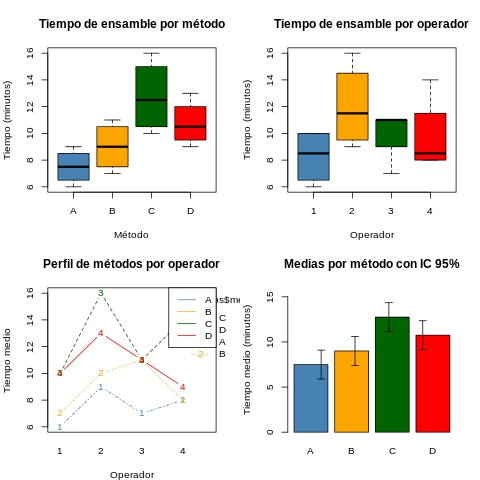

In [ ]:


# ============================================
# @title **B. EJEMPLO: DBCA - COMPARACIÓN DE MÉTODOS DE ENSAMBLE**
# ============================================
%%R
# Datos
tiempo <- c(6, 7, 10, 10,   # Operador 1
            9, 10, 16, 13,  # Operador 2
            7, 11, 11, 11,  # Operador 3
            8, 8, 14, 9)    # Operador 4

metodo <- factor(rep(c("A", "B", "C", "D"), times = 4))
operador <- factor(rep(1:4, each = 4))

datos <- data.frame(tiempo, metodo, operador)

# Estadísticos descriptivos
library(dplyr)
resumen_trat <- datos %>%
  group_by(metodo) %>%
  summarise(n = n(), media = mean(tiempo), sd = sd(tiempo))

resumen_bloque <- datos %>%
  group_by(operador) %>%
  summarise(n = n(), media = mean(tiempo), sd = sd(tiempo))

print("=== ESTADÍSTICOS POR TRATAMIENTO ===")
print(resumen_trat)

print("=== ESTADÍSTICOS POR BLOQUE ===")
print(resumen_bloque)

# ANOVA para DBCA
modelo_dbca <- aov(tiempo ~ metodo + operador, data = datos)
summary(modelo_dbca)

# Comparación con DCA (sin bloque)
modelo_dca <- aov(tiempo ~ metodo, data = datos)
summary(modelo_dca)

# Comparaciones múltiples (LSD)
CME <- summary(modelo_dbca)[[1]]$`Mean Sq`[3]
gl_error <- summary(modelo_dbca)[[1]]$Df[3]
b <- length(unique(operador))  # número de bloques
t_critico <- qt(0.975, gl_error)
LSD <- t_critico * sqrt(2 * CME / b)

cat("\n=== COMPARACIONES MÚLTIPLES (LSD) ===\n")
cat("CME =", round(CME, 4), "\n")
cat("t crítico (α=0.05) =", round(t_critico, 4), "\n")
cat("LSD =", round(LSD, 4), "\n\n")

# Matriz de diferencias entre medias
medias <- tapply(tiempo, metodo, mean)
diferencias <- outer(medias, medias, "-")

cat("Diferencias entre medias:\n")
print(round(diferencias, 2))

cat("\nDiferencias significativas (|diferencia| > LSD):\n")
for (i in 1:4) {
  for (j in 1:4) {
    if (i < j && abs(diferencias[i,j]) > LSD) {
      cat(names(medias)[i], "-", names(medias)[j], ":",
          round(diferencias[i,j], 2), ">", round(LSD, 2), "→ Diferente\n")
    }
  }
}

# Prueba de Tukey HSD
tukey_result <- TukeyHSD(modelo_dbca, "metodo")
print(tukey_result)

# Gráficos
par(mfrow = c(2, 2), mar = c(4, 4, 4, 2))

# Boxplot por método
boxplot(tiempo ~ metodo, data = datos,
        col = c("steelblue", "orange", "darkgreen", "red"),
        main = "Tiempo de ensamble por método",
        xlab = "Método", ylab = "Tiempo (minutos)")

# Boxplot por operador (bloque)
boxplot(tiempo ~ operador, data = datos,
        col = c("steelblue", "orange", "darkgreen", "red"),
        main = "Tiempo de ensamble por operador",
        xlab = "Operador", ylab = "Tiempo (minutos)")

# Gráfico de interacción
interaction.plot(datos$operador, datos$metodo, datos$tiempo,
                 type = "b", col = c("steelblue", "orange", "darkgreen", "red"),
                 xlab = "Operador", ylab = "Tiempo medio",
                 main = "Perfil de métodos por operador")
legend("topright", legend = c("A", "B", "C", "D"),
       col = c("steelblue", "orange", "darkgreen", "red"), lty = 1)

# Gráfico de medias con intervalos de confianza
medias_trat <- resumen_trat$media
errores <- sqrt(CME / b) * t_critico
barplot(medias_trat, names.arg = c("A", "B", "C", "D"),
        col = c("steelblue", "orange", "darkgreen", "red"),
        ylim = c(0, 16), ylab = "Tiempo medio (minutos)",
        main = "Medias por método con IC 95%")
arrows(1:4, medias_trat - errores, 1:4, medias_trat + errores,
       angle = 90, code = 3, length = 0.05)




=== ESTADÍSTICOS POR TRATAMIENTO ===
        count   mean       std
metodo                        
A           4   7.50  1.290994
B           4   9.00  1.825742
C           4  12.75  2.753785
D           4  10.75  1.707825

=== ESTADÍSTICOS POR BLOQUE ===
          count   mean       std
operador                        
1             4   8.25  2.061553
2             4  12.00  3.162278
3             4  10.00  2.000000
4             4   9.75  2.872281

=== TABLA ANOVA (DBCA) ===
             sum_sq   df      F    PR(>F)
C(metodo)      61.5  3.0  10.25  0.002919
C(operador)    28.5  3.0   4.75  0.029846
Residual       18.0  9.0    NaN       NaN

=== TABLA ANOVA (DCA) ===
           sum_sq    df         F    PR(>F)
C(metodo)    61.5   3.0  5.290323  0.014827
Residual     46.5  12.0       NaN       NaN

=== COMPARACIONES MÚLTIPLES (LSD) ===
CME = 2.0000
t crítico (α=0.05) = 2.2622
LSD = 2.2622

Diferencias entre medias:
metodo     A     B     C     D
metodo                        
A       0

/tmp/ipykernel_37615/3871392999.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('metodo')['tiempo'].agg(['count', 'mean', 'std']))
/tmp/ipykernel_37615/3871392999.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('operador')['tiempo'].agg(['count', 'mean', 'std']))
/tmp/ipykernel_37615/3871392999.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medias = datos.groupby('m

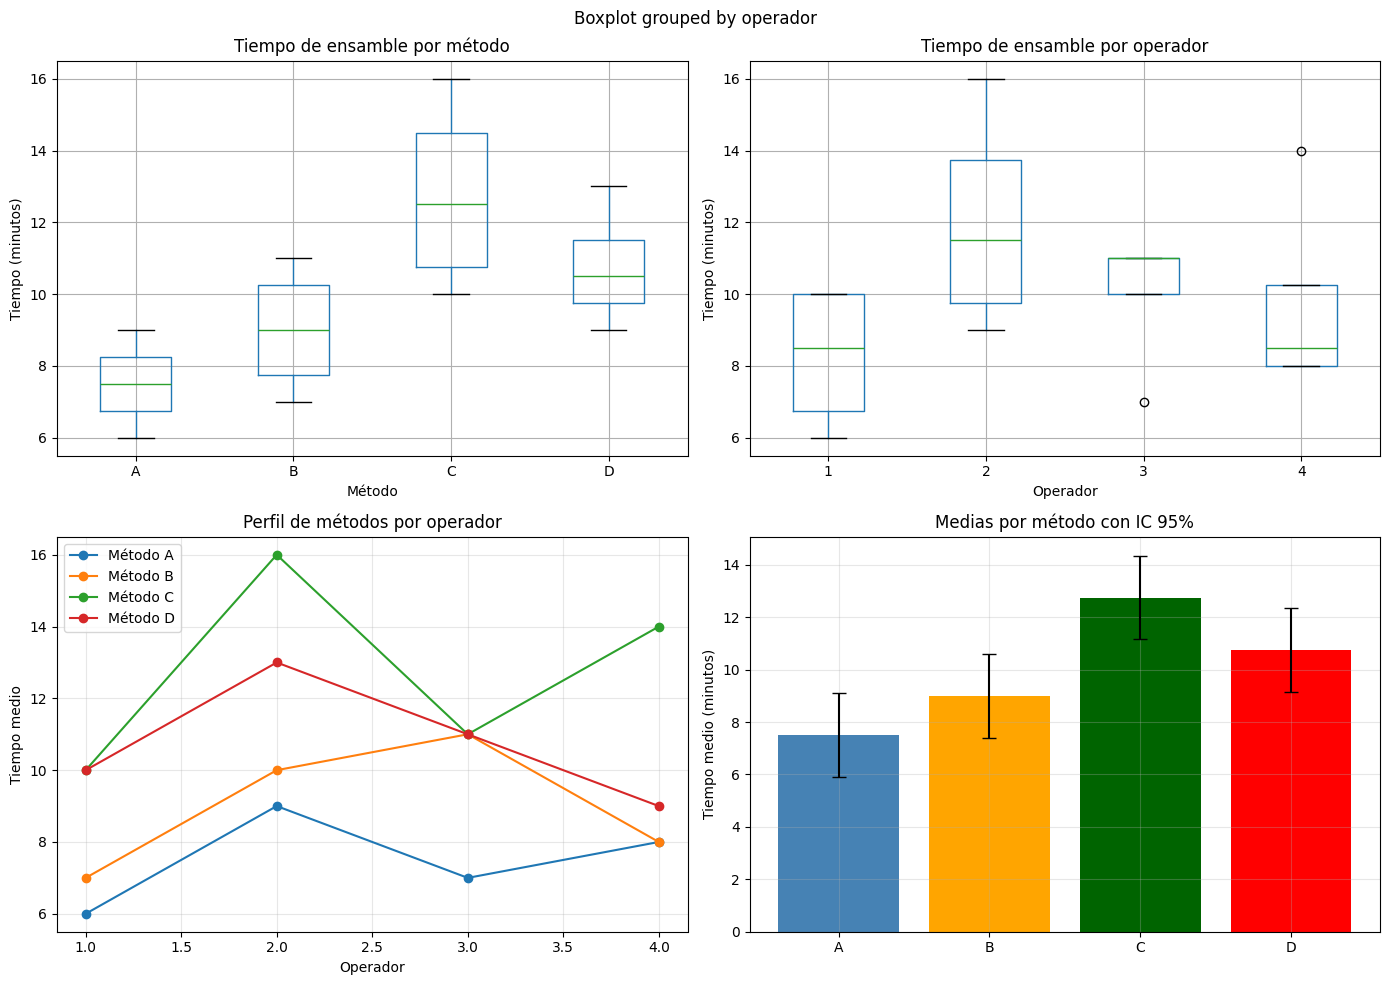


=== COMPARACIÓN DBCA vs DCA ===
DBCA - Error cuadrático medio: 2.0000
DCA - Error cuadrático medio: 3.8750
Reducción del error: 48.4%


In [ ]:
# ============================================
# @title **C.  EJEMPLO: DBCA - COMPARACIÓN DE MÉTODOS DE ENSAMBLE**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f, t

# Datos
tiempo = [6, 7, 10, 10, 9, 10, 16, 13, 7, 11, 11, 11, 8, 8, 14, 9]
metodo = ['A', 'B', 'C', 'D'] * 4
operador = [1]*4 + [2]*4 + [3]*4 + [4]*4

datos = pd.DataFrame({'tiempo': tiempo, 'metodo': metodo, 'operador': operador})
datos['metodo'] = datos['metodo'].astype('category')
datos['operador'] = datos['operador'].astype('category')

# Estadísticos descriptivos
print("=== ESTADÍSTICOS POR TRATAMIENTO ===")
print(datos.groupby('metodo')['tiempo'].agg(['count', 'mean', 'std']))

print("\n=== ESTADÍSTICOS POR BLOQUE ===")
print(datos.groupby('operador')['tiempo'].agg(['count', 'mean', 'std']))

# ANOVA para DBCA
modelo_dbca = ols('tiempo ~ C(metodo) + C(operador)', data=datos).fit()
anova_dbca = sm.stats.anova_lm(modelo_dbca, typ=2)
print("\n=== TABLA ANOVA (DBCA) ===")
print(anova_dbca)

# ANOVA para DCA (sin bloque)
modelo_dca = ols('tiempo ~ C(metodo)', data=datos).fit()
anova_dca = sm.stats.anova_lm(modelo_dca, typ=2)
print("\n=== TABLA ANOVA (DCA) ===")
print(anova_dca)

# Comparaciones múltiples (LSD)
CME = anova_dbca.loc['Residual', 'sum_sq'] / anova_dbca.loc['Residual', 'df']
gl_error = anova_dbca.loc['Residual', 'df']
b = len(datos['operador'].unique())
t_critico = t.ppf(0.975, gl_error)
LSD = t_critico * np.sqrt(2 * CME / b)

print("\n=== COMPARACIONES MÚLTIPLES (LSD) ===")
print(f"CME = {CME:.4f}")
print(f"t crítico (α=0.05) = {t_critico:.4f}")
print(f"LSD = {LSD:.4f}")

# Matriz de diferencias entre medias
medias = datos.groupby('metodo')['tiempo'].mean()
diferencias = np.zeros((4, 4))
for i, m1 in enumerate(medias.index):
    for j, m2 in enumerate(medias.index):
        diferencias[i, j] = medias[m1] - medias[m2]

print("\nDiferencias entre medias:")
print(pd.DataFrame(diferencias, index=medias.index, columns=medias.index).round(2))

print("\nDiferencias significativas (|diferencia| > LSD):")
for i, m1 in enumerate(medias.index):
    for j, m2 in enumerate(medias.index):
        if i < j and abs(diferencias[i, j]) > LSD:
            print(f"{m1} - {m2}: {diferencias[i, j]:.2f} > {LSD:.2f} → Diferente")

# Prueba de Tukey HSD
tukey = pairwise_tukeyhsd(datos['tiempo'], datos['metodo'], alpha=0.05)
print("\n=== TUKEY HSD ===")
print(tukey)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot por método
datos.boxplot(column='tiempo', by='metodo', ax=axes[0, 0])
axes[0, 0].set_title('Tiempo de ensamble por método')
axes[0, 0].set_xlabel('Método')
axes[0, 0].set_ylabel('Tiempo (minutos)')

# Boxplot por operador
datos.boxplot(column='tiempo', by='operador', ax=axes[0, 1])
axes[0, 1].set_title('Tiempo de ensamble por operador')
axes[0, 1].set_xlabel('Operador')
axes[0, 1].set_ylabel('Tiempo (minutos)')

# Gráfico de perfil (interacción)
for metodo in medias.index:
    datos_metodo = datos[datos['metodo'] == metodo]
    medios = [datos_metodo[datos_metodo['operador'] == op]['tiempo'].mean()
              for op in range(1, 5)]
    axes[1, 0].plot(range(1, 5), medios, 'o-', label=f'Método {metodo}')
axes[1, 0].set_xlabel('Operador')
axes[1, 0].set_ylabel('Tiempo medio')
axes[1, 0].set_title('Perfil de métodos por operador')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfico de medias con intervalos de confianza
errores = np.sqrt(CME / b) * t_critico
axes[1, 1].bar(medias.index, medias.values,
               color=['steelblue', 'orange', 'darkgreen', 'red'])
axes[1, 1].errorbar(medias.index, medias.values, yerr=errores,
                    fmt='none', capsize=5, color='black')
axes[1, 1].set_ylabel('Tiempo medio (minutos)')
axes[1, 1].set_title('Medias por método con IC 95%')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparación de ANOVA DBCA vs DCA
print("\n=== COMPARACIÓN DBCA vs DCA ===")
print(f"DBCA - Error cuadrático medio: {CME:.4f}")
print(f"DCA - Error cuadrático medio: {anova_dca.loc['Residual', 'sum_sq'] / anova_dca.loc['Residual', 'df']:.4f}")
print(f"Reducción del error: {(1 - CME/(anova_dca.loc['Residual', 'sum_sq'] / anova_dca.loc['Residual', 'df']))*100:.1f}%")


[⬆️ Volver al inicio](#inicio5)

<a name="T37"></a>
## **37.  EJEMPLO: DISEÑO EN CUADRO LATINO**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

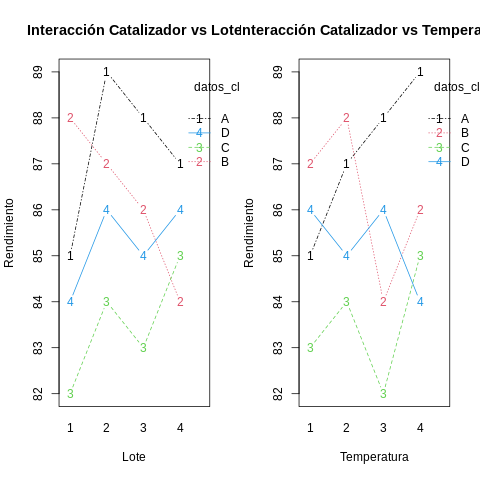

In [ ]:


# ============================================
# @title **B. EJEMPLO: DISEÑO EN CUADRO LATINO**
# ============================================
%%R
# Supongamos un experimento para evaluar 4 catalizadores (A, B, C, D)
# con 4 lotes de materia prima (filas) y 4 temperaturas (columnas)

# Datos simulados
set.seed(123)
catalizador <- c("A", "B", "C", "D",
                 "B", "C", "D", "A",
                 "C", "D", "A", "B",
                 "D", "A", "B", "C")

lote <- factor(rep(1:4, each = 4))
temperatura <- factor(rep(1:4, times = 4))

# Respuesta simulada (rendimiento)
rendimiento <- c(85, 88, 82, 84,
                 87, 84, 86, 89,
                 83, 85, 88, 86,
                 86, 87, 84, 85)

datos_cl <- data.frame(rendimiento, catalizador, lote, temperatura)

# ANOVA para Cuadro Latino
modelo_cl <- aov(rendimiento ~ catalizador + lote + temperatura, data = datos_cl)
summary(modelo_cl)

# Visualización
par(mfrow = c(1, 2))
interaction.plot(datos_cl$lote, datos_cl$catalizador, datos_cl$rendimiento,
                 type = "b", col = 1:4, xlab = "Lote", ylab = "Rendimiento",
                 main = "Interacción Catalizador vs Lote")

interaction.plot(datos_cl$temperatura, datos_cl$catalizador, datos_cl$rendimiento,
                 type = "b", col = 1:4, xlab = "Temperatura", ylab = "Rendimiento",
                 main = "Interacción Catalizador vs Temperatura")




=== ANOVA CUADRO LATINO ===
                 sum_sq   df         F    PR(>F)
C(catalizador)   3.1875  3.0  0.205369  0.890130
C(lote)          6.1875  3.0  0.398658  0.757344
C(temperatura)   3.1875  3.0  0.205369  0.890130
Residual        46.5625  9.0       NaN       NaN


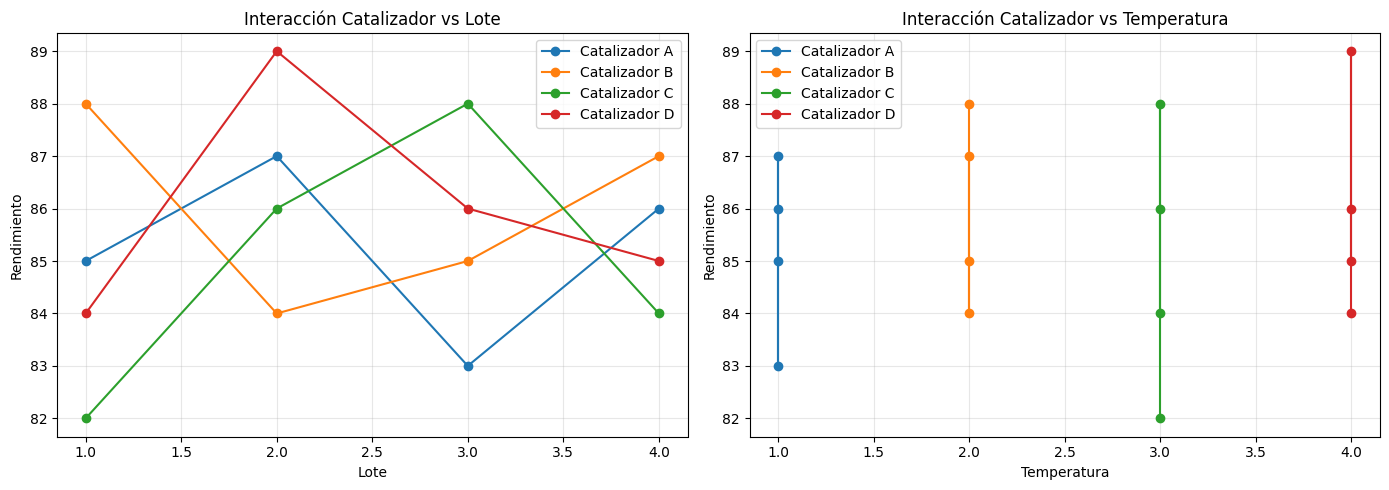

In [ ]:
# ============================================
# @title **C.  EJEMPLO: DISEÑO EN CUADRO LATINO**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Datos
np.random.seed(123)
catalizador = ['A', 'B', 'C', 'D'] * 4
lote = [1]*4 + [2]*4 + [3]*4 + [4]*4
temperatura = [1,2,3,4] * 4

# Respuesta simulada
rendimiento = [85, 88, 82, 84, 87, 84, 86, 89, 83, 85, 88, 86, 86, 87, 84, 85]

datos_cl = pd.DataFrame({
    'rendimiento': rendimiento,
    'catalizador': catalizador,
    'lote': lote,
    'temperatura': temperatura
})

# ANOVA
modelo_cl = ols('rendimiento ~ C(catalizador) + C(lote) + C(temperatura)', data=datos_cl).fit()
anova_cl = sm.stats.anova_lm(modelo_cl, typ=2)
print("=== ANOVA CUADRO LATINO ===")
print(anova_cl)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cat in datos_cl['catalizador'].unique():
    datos_cat = datos_cl[datos_cl['catalizador'] == cat]
    axes[0].plot(datos_cat['lote'], datos_cat['rendimiento'], 'o-', label=f'Catalizador {cat}')
axes[0].set_xlabel('Lote')
axes[0].set_ylabel('Rendimiento')
axes[0].set_title('Interacción Catalizador vs Lote')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for cat in datos_cl['catalizador'].unique():
    datos_cat = datos_cl[datos_cl['catalizador'] == cat]
    axes[1].plot(datos_cat['temperatura'], datos_cat['rendimiento'], 'o-', label=f'Catalizador {cat}')
axes[1].set_xlabel('Temperatura')
axes[1].set_ylabel('Rendimiento')
axes[1].set_title('Interacción Catalizador vs Temperatura')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<a name="T38"></a>
## **38.  EJEMPLO: DISEÑO EN CUADRO LATINO - LLANTAS**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[1] "=== MEDIAS POR MARCA ==="
# A tibble: 4 × 2
  marca media
  <chr> <dbl>
1 A      14.2
2 B      12.2
3 C      10.8
4 D      11  
[1] "=== MEDIAS POR POSICIÓN ==="
# A tibble: 4 × 2
  posicion media
  <fct>    <dbl>
1 1         11  
2 2         12.5
3 3         12.5
4 4         12.2
[1] "=== MEDIAS POR CARRO ==="
# A tibble: 4 × 2
  carro media
  <fct> <dbl>
1 1     14   
2 2     12.8 
3 3     11.8 
4 4      9.75

=== COMPARACIONES MÚLTIPLES (LSD) ===
CME = 0.8958 
t crítico = 2.4469 
LSD = 1.6376 

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = desgaste ~ marca + posicion + carro, data = datos)

$marca
     diff       lwr        upr     p adj
B-A -2.00 -4.316805  0.3168049 0.0872429
C-A -3.50 -5.816805 -1.1831951 0.0078229
D-A -3.25 -5.566805 -0.9331951 0.0112170
C-B -1.50 -3.816805  0.8168049 0.2144635
D-B -1.25 -3.566805  1.0668049 0.3315951
D-C  0.25 -2.066805  2.5668049 0.9805997



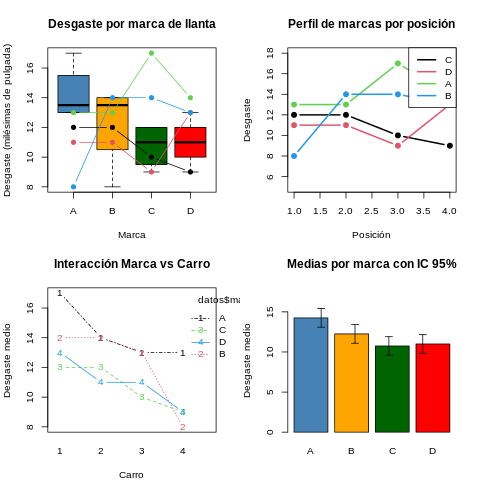

In [ ]:

# ============================================
# @title **B. EJEMPLO: DISEÑO EN CUADRO LATINO - LLANTAS**
# ============================================
%%R
# Datos
marca <- c("C", "D", "A", "B",
           "B", "C", "D", "A",
           "A", "B", "C", "D",
           "D", "A", "B", "C")

desgaste <- c(12, 11, 13, 8,
              14, 12, 11, 13,
              17, 14, 10, 9,
              13, 14, 13, 9)

posicion <- factor(rep(1:4, each = 4))
carro <- factor(rep(1:4, times = 4))

datos <- data.frame(desgaste, marca, posicion, carro)

# Estadísticos descriptivos
library(dplyr)

print("=== MEDIAS POR MARCA ===")
medias_marca <- datos %>% group_by(marca) %>% summarise(media = mean(desgaste))
print(medias_marca)

print("=== MEDIAS POR POSICIÓN ===")
medias_posicion <- datos %>% group_by(posicion) %>% summarise(media = mean(desgaste))
print(medias_posicion)

print("=== MEDIAS POR CARRO ===")
medias_carro <- datos %>% group_by(carro) %>% summarise(media = mean(desgaste))
print(medias_carro)

# ANOVA para Cuadro Latino
modelo_cl <- aov(desgaste ~ marca + posicion + carro, data = datos)
summary(modelo_cl)

# Comparaciones múltiples (LSD)
CME <- summary(modelo_cl)[[1]]$`Mean Sq`[4]
gl_error <- summary(modelo_cl)[[1]]$Df[4]
k <- 4
t_critico <- qt(0.975, gl_error)
LSD <- t_critico * sqrt(2 * CME / k)

cat("\n=== COMPARACIONES MÚLTIPLES (LSD) ===\n")
cat("CME =", round(CME, 4), "\n")
cat("t crítico =", round(t_critico, 4), "\n")
cat("LSD =", round(LSD, 4), "\n\n")

# Prueba de Tukey HSD
tukey_result <- TukeyHSD(modelo_cl, "marca")
print(tukey_result)

# Gráficos
par(mfrow = c(2, 2), mar = c(4, 4, 4, 2))

# Boxplot por marca
boxplot(desgaste ~ marca, data = datos,
        col = c("steelblue", "orange", "darkgreen", "red"),
        main = "Desgaste por marca de llanta",
        xlab = "Marca", ylab = "Desgaste (milésimas de pulgada)")

# Gráfico de perfil por posición
for(m in unique(datos$marca)) {
  subdatos <- datos[datos$marca == m, ]
  lines(subdatos$posicion, subdatos$desgaste, type = "b",
        col = which(unique(datos$marca) == m), pch = 19)
}
plot(1, type = "n", xlim = c(1,4), ylim = c(5, 18),
     xlab = "Posición", ylab = "Desgaste",
     main = "Perfil de marcas por posición")
for(m in unique(datos$marca)) {
  subdatos <- datos[datos$marca == m, ]
  lines(subdatos$posicion, subdatos$desgaste, type = "b",
        col = which(unique(datos$marca) == m), lwd = 2, pch = 19)
}
legend("topright", legend = unique(datos$marca),
       col = 1:4, lty = 1, lwd = 2)

# Gráfico de interacción
interaction.plot(datos$carro, datos$marca, datos$desgaste,
                 type = "b", col = 1:4,
                 xlab = "Carro", ylab = "Desgaste medio",
                 main = "Interacción Marca vs Carro")

# Gráfico de medias con IC
medias <- tapply(desgaste, marca, mean)
errores <- sqrt(CME / k) * t_critico
barplot(medias, col = c("steelblue", "orange", "darkgreen", "red"),
        ylim = c(0, 18), ylab = "Desgaste medio",
        main = "Medias por marca con IC 95%")
arrows(1:4, medias - errores, 1:4, medias + errores,
       angle = 90, code = 3, length = 0.05)



=== MEDIAS POR MARCA ===
marca
A    14.25
B    12.25
C    10.75
D    11.00
Name: desgaste, dtype: float64

=== MEDIAS POR POSICIÓN ===
posicion
1    11.00
2    12.50
3    12.50
4    12.25
Name: desgaste, dtype: float64

=== MEDIAS POR CARRO ===
carro
1    14.00
2    12.75
3    11.75
4     9.75
Name: desgaste, dtype: float64

=== ANOVA CUADRO LATINO ===
              sum_sq   df          F    PR(>F)
C(marca)     30.6875  3.0  11.418605  0.006825
C(posicion)   6.1875  3.0   2.302326  0.176947
C(carro)     38.6875  3.0  14.395349  0.003784
Residual      5.3750  6.0        NaN       NaN

=== COMPARACIONES MÚLTIPLES (LSD) ===
CME = 0.8958
t crítico = 2.4469
LSD = 1.6376

=== TUKEY HSD ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B     -2.0 0.5327 -6.2959 2.2959  False
     A      C     -3.5 0.1261 -7.7959 0.7959  False
     A      D    -3.25 0.1661 -7.5459 1.0459  F

/tmp/ipykernel_37615/748503162.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('marca')['desgaste'].mean())
/tmp/ipykernel_37615/748503162.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('posicion')['desgaste'].mean())
/tmp/ipykernel_37615/748503162.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('carro')['desgaste'].mean())
/tmp/ipykernel_37615/7

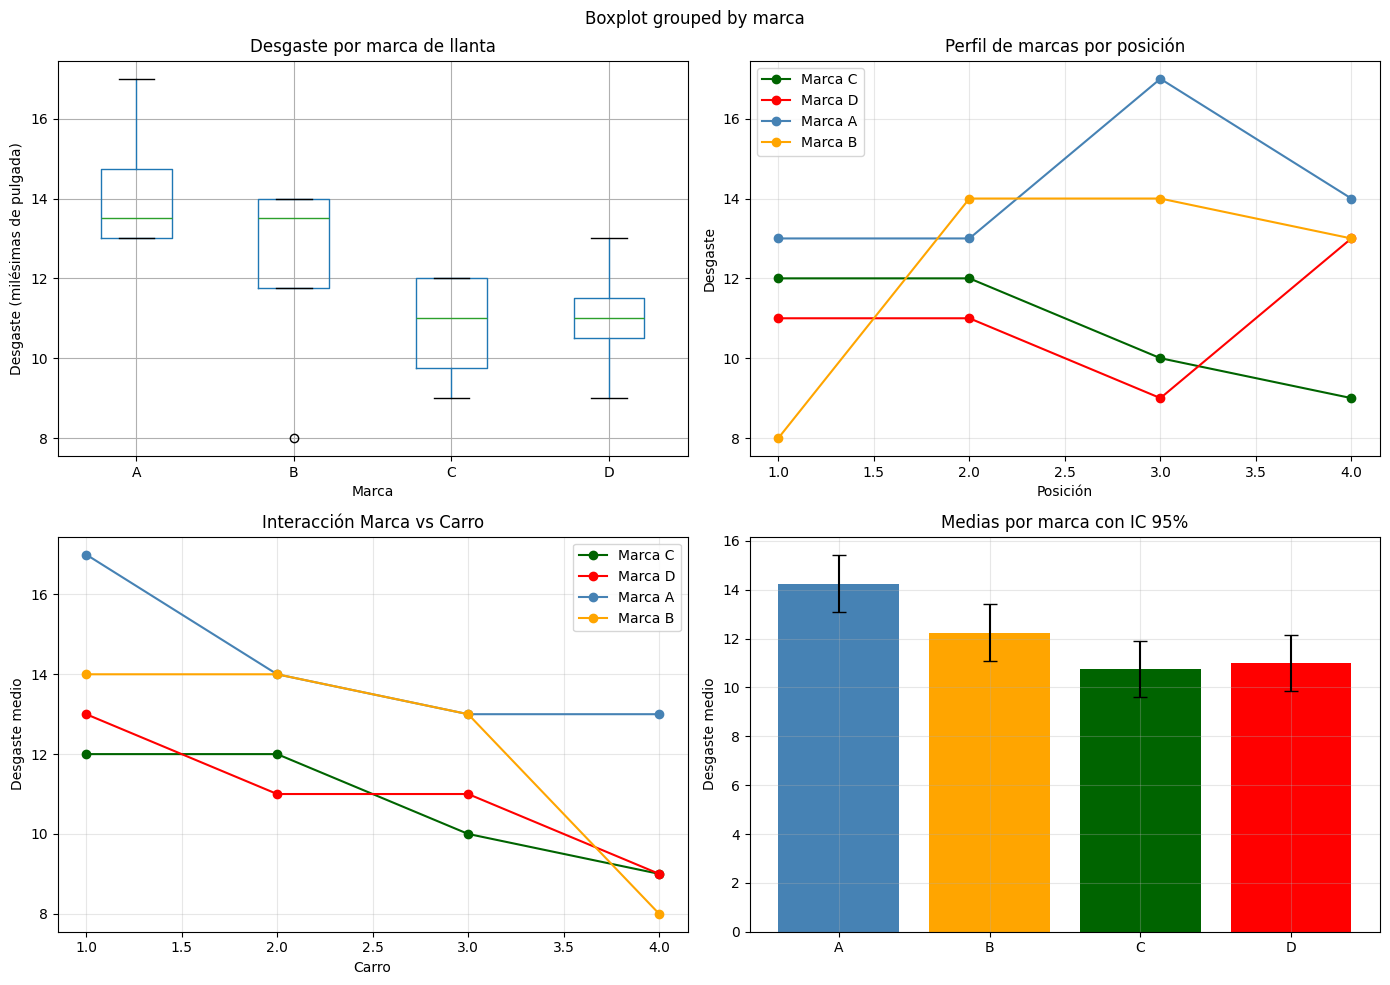


=== CONCLUSIONES ===
F para marcas = 11.4186
p-valor = 0.0068
→ Existen diferencias significativas entre las marcas de llanta.


In [ ]:
# ============================================
# @title **C.  EJEMPLO: DISEÑO EN CUADRO LATINO - LLANTAS**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f, t

# Datos
marca = ['C', 'D', 'A', 'B', 'B', 'C', 'D', 'A',
         'A', 'B', 'C', 'D', 'D', 'A', 'B', 'C']
desgaste = [12, 11, 13, 8, 14, 12, 11, 13,
            17, 14, 10, 9, 13, 14, 13, 9]
posicion = [1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4]
carro = [1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4]

datos = pd.DataFrame({
    'desgaste': desgaste,
    'marca': marca,
    'posicion': posicion,
    'carro': carro
})
datos['marca'] = datos['marca'].astype('category')
datos['posicion'] = datos['posicion'].astype('category')
datos['carro'] = datos['carro'].astype('category')

# Estadísticos descriptivos
print("=== MEDIAS POR MARCA ===")
print(datos.groupby('marca')['desgaste'].mean())

print("\n=== MEDIAS POR POSICIÓN ===")
print(datos.groupby('posicion')['desgaste'].mean())

print("\n=== MEDIAS POR CARRO ===")
print(datos.groupby('carro')['desgaste'].mean())

# ANOVA para Cuadro Latino
modelo_cl = ols('desgaste ~ C(marca) + C(posicion) + C(carro)', data=datos).fit()
anova_cl = sm.stats.anova_lm(modelo_cl, typ=2)
print("\n=== ANOVA CUADRO LATINO ===")
print(anova_cl)

# Extraer componentes
CME = anova_cl.loc['Residual', 'sum_sq'] / anova_cl.loc['Residual', 'df']
gl_error = anova_cl.loc['Residual', 'df']
k = 4
t_critico = t.ppf(0.975, gl_error)
LSD = t_critico * np.sqrt(2 * CME / k)

print(f"\n=== COMPARACIONES MÚLTIPLES (LSD) ===")
print(f"CME = {CME:.4f}")
print(f"t crítico = {t_critico:.4f}")
print(f"LSD = {LSD:.4f}")

# Prueba de Tukey HSD
tukey = pairwise_tukeyhsd(datos['desgaste'], datos['marca'], alpha=0.05)
print("\n=== TUKEY HSD ===")
print(tukey)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot por marca
datos.boxplot(column='desgaste', by='marca', ax=axes[0, 0])
axes[0, 0].set_title('Desgaste por marca de llanta')
axes[0, 0].set_xlabel('Marca')
axes[0, 0].set_ylabel('Desgaste (milésimas de pulgada)')

# Perfil por posición
colores = {'A': 'steelblue', 'B': 'orange', 'C': 'darkgreen', 'D': 'red'}
for marca_val in datos['marca'].unique():
    subdatos = datos[datos['marca'] == marca_val]
    axes[0, 1].plot(subdatos['posicion'], subdatos['desgaste'],
                    'o-', color=colores[marca_val], label=f'Marca {marca_val}')
axes[0, 1].set_xlabel('Posición')
axes[0, 1].set_ylabel('Desgaste')
axes[0, 1].set_title('Perfil de marcas por posición')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gráfico de interacción
for marca_val in datos['marca'].unique():
    subdatos = datos[datos['marca'] == marca_val]
    medias = subdatos.groupby('carro')['desgaste'].mean()
    axes[1, 0].plot(medias.index, medias.values, 'o-',
                    color=colores[marca_val], label=f'Marca {marca_val}')
axes[1, 0].set_xlabel('Carro')
axes[1, 0].set_ylabel('Desgaste medio')
axes[1, 0].set_title('Interacción Marca vs Carro')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Medias con IC
medias = datos.groupby('marca')['desgaste'].mean()
errores = np.sqrt(CME / k) * t_critico
axes[1, 1].bar(medias.index, medias.values,
               color=['steelblue', 'orange', 'darkgreen', 'red'])
axes[1, 1].errorbar(medias.index, medias.values, yerr=errores,
                    fmt='none', capsize=5, color='black')
axes[1, 1].set_ylabel('Desgaste medio')
axes[1, 1].set_title('Medias por marca con IC 95%')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resultados
print("\n=== CONCLUSIONES ===")
print(f"F para marcas = {anova_cl.loc['C(marca)', 'F']:.4f}")
print(f"p-valor = {anova_cl.loc['C(marca)', 'PR(>F)']:.4f}")
if anova_cl.loc['C(marca)', 'PR(>F)'] < 0.05:
    print("→ Existen diferencias significativas entre las marcas de llanta.")
else:
    print("→ No hay diferencias significativas entre las marcas.")


[⬆️ Volver al inicio](#inicio5)

<a name="T39"></a>
## **39. EJEMPLO: DISEÑO EN CUADRO GRECOLATINO RENDIMIENTO DE PROCESO QUÍMICO**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== MEDIAS POR TRATAMIENTO (TIEMPO) ===
# A tibble: 5 × 4
  tratamiento     n media    sd
  <fct>       <int> <dbl> <dbl>
1 A               5  23.6  2.07
2 B               5  15.6  2.07
3 C               5  18.8  1.79
4 D               5  15    2.24
5 E               5  13    2.55

=== MEDIAS POR LOTE ===
# A tibble: 5 × 4
  lote      n media    sd
  <fct> <int> <dbl> <dbl>
1 1         5  18    4.95
2 2         5  17.8  4.09
3 3         5  17.2  5.36
4 4         5  16.6  3.21
5 5         5  16.4  5.13

=== MEDIAS POR CONCENTRACIÓN DE ÁCIDO ===
# A tibble: 5 × 4
  acido     n media    sd
  <fct> <int> <dbl> <dbl>
1 1         5  17.8  5.93
2 2         5  17.6  4.83
3 3         5  18.4  2.30
4 4         5  16.6  5.22
5 5         5  15.6  3.44

=== MEDIAS POR CATALIZADOR ===
# A tibble: 5 × 4
  catalizador     n media    sd
  <fct>       <int> <dbl> <dbl>
1 α               5  16.6  5.94
2 β               5  17    2.35
3 γ               5  18.2  4.32
4 δ               5  16.4  5.13
5 ε     

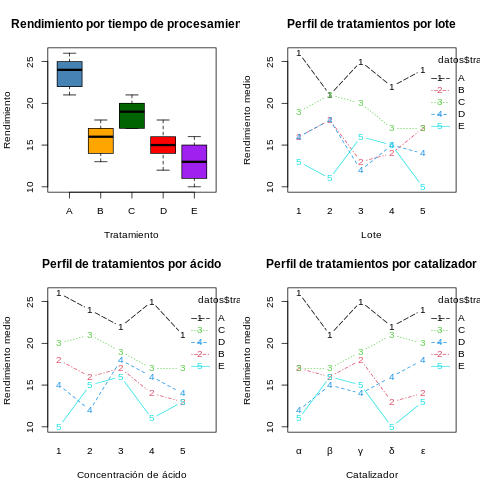

In [ ]:


# ============================================
# @title **B. EJEMPLO: DISEÑO EN CUADRO GRECOLATINO**
# RENDIMIENTO DE PROCESO QUÍMICO
# ============================================
%%R
# Datos del experimento
rendimiento <- c(26, 16, 19, 16, 13,
                 18, 21, 18, 11, 21,
                 20, 12, 16, 25, 13,
                 15, 15, 22, 14, 17,
                 10, 24, 17, 17, 14)

# Factores
lote <- factor(rep(1:5, each = 5))
acido <- factor(rep(1:5, times = 5))
tratamiento <- factor(c("A", "B", "C", "D", "E",
                        "B", "C", "D", "E", "A",
                        "C", "D", "E", "A", "B",
                        "D", "E", "A", "B", "C",
                        "E", "A", "B", "C", "D"))
catalizador <- factor(c("α", "β", "γ", "δ", "ε",
                        "γ", "δ", "ε", "α", "β",
                        "ε", "α", "β", "γ", "δ",
                        "β", "γ", "δ", "ε", "α",
                        "δ", "ε", "α", "β", "γ"))

datos <- data.frame(rendimiento, lote, acido, tratamiento, catalizador)

# ============================================
# 1. ESTADÍSTICOS DESCRIPTIVOS
# ============================================
library(dplyr)

cat("=== MEDIAS POR TRATAMIENTO (TIEMPO) ===\n")
medias_trat <- datos %>% group_by(tratamiento) %>% summarise(
  n = n(), media = mean(rendimiento), sd = sd(rendimiento))
print(medias_trat)

cat("\n=== MEDIAS POR LOTE ===\n")
medias_lote <- datos %>% group_by(lote) %>% summarise(
  n = n(), media = mean(rendimiento), sd = sd(rendimiento))
print(medias_lote)

cat("\n=== MEDIAS POR CONCENTRACIÓN DE ÁCIDO ===\n")
medias_acido <- datos %>% group_by(acido) %>% summarise(
  n = n(), media = mean(rendimiento), sd = sd(rendimiento))
print(medias_acido)

cat("\n=== MEDIAS POR CATALIZADOR ===\n")
medias_cat <- datos %>% group_by(catalizador) %>% summarise(
  n = n(), media = mean(rendimiento), sd = sd(rendimiento))
print(medias_cat)

# ============================================
# 2. ANOVA PARA CUADRO GRECOLATINO
# ============================================
modelo_gcl <- aov(rendimiento ~ tratamiento + lote + acido + catalizador,
                  data = datos)
summary(modelo_gcl)

# ============================================
# 3. COMPARACIONES MÚLTIPLES (Tukey HSD)
# ============================================
tukey_trat <- TukeyHSD(modelo_gcl, "tratamiento")
print(tukey_trat)

# ============================================
# 4. VERIFICACIÓN DE SUPUESTOS
# ============================================
par(mfrow = c(2, 2), mar = c(4, 4, 4, 2))

# Residuos
residuos <- residuals(modelo_gcl)
valores_ajustados <- fitted(modelo_gcl)

# Gráfica de residuos vs ajustados
plot(valores_ajustados, residuos, pch = 19, col = "steelblue",
     xlab = "Valores ajustados", ylab = "Residuos",
     main = "Residuos vs Ajustados")
abline(h = 0, col = "red", lty = 2)

# Q-Q plot
qqnorm(residuos, pch = 19, col = "steelblue", main = "Q-Q Plot de residuos")
qqline(residuos, col = "red", lwd = 2)

# Histograma de residuos
hist(residuos, breaks = 8, prob = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5), border = "white",
     main = "Histograma de residuos", xlab = "Residuos")
curve(dnorm(x, mean(residuos), sd(residuos)), add = TRUE,
      col = "red", lwd = 2)

# Prueba de Shapiro-Wilk
shapiro_test <- shapiro.test(residuos)
cat("\n=== PRUEBA DE SHAPIRO-WILK ===\n")
cat("Estadístico W:", round(shapiro_test$statistic, 4), "\n")
cat("Valor-p:", round(shapiro_test$p.value, 4), "\n")

# ============================================
# 5. GRÁFICAS DE PERFIL
# ============================================
par(mfrow = c(2, 2), mar = c(4, 4, 4, 2))

# Gráfico de medias por tratamiento
boxplot(rendimiento ~ tratamiento, data = datos,
        col = c("steelblue", "orange", "darkgreen", "red", "purple"),
        main = "Rendimiento por tiempo de procesamiento",
        xlab = "Tratamiento", ylab = "Rendimiento")

# Gráfico de perfil por lote
interaction.plot(datos$lote, datos$tratamiento, datos$rendimiento,
                 type = "b", col = 1:5, xlab = "Lote", ylab = "Rendimiento medio",
                 main = "Perfil de tratamientos por lote")

# Gráfico de perfil por ácido
interaction.plot(datos$acido, datos$tratamiento, datos$rendimiento,
                 type = "b", col = 1:5, xlab = "Concentración de ácido",
                 ylab = "Rendimiento medio",
                 main = "Perfil de tratamientos por ácido")

# Gráfico de perfil por catalizador
interaction.plot(datos$catalizador, datos$tratamiento, datos$rendimiento,
                 type = "b", col = 1:5, xlab = "Catalizador",
                 ylab = "Rendimiento medio",
                 main = "Perfil de tratamientos por catalizador")




=== MEDIAS POR TRATAMIENTO (TIEMPO) ===
             count  mean       std
tratamiento                       
A                5  23.6  2.073644
B                5  15.6  2.073644
C                5  18.8  1.788854
D                5  15.0  2.236068
E                5  13.0  2.549510

=== MEDIAS POR LOTE ===
      count  mean       std
lote                       
1         5  18.0  4.949747
2         5  17.8  4.086563
3         5  17.2  5.357238
4         5  16.6  3.209361
5         5  16.4  5.128353

=== MEDIAS POR CONCENTRACIÓN DE ÁCIDO ===
       count  mean       std
acido                       
1          5  17.8  5.932959
2          5  17.6  4.827007
3          5  18.4  2.302173
4          5  16.6  5.224940
5          5  15.6  3.435113

=== MEDIAS POR CATALIZADOR ===
             count  mean       std
catalizador                       
α                5  16.6  5.941380
β                5  17.0  2.345208
γ                5  18.2  4.324350
δ                5  16.4  5.128353
ε     

/tmp/ipykernel_37615/3977433768.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('tratamiento')['rendimiento'].agg(['count', 'mean', 'std']))
/tmp/ipykernel_37615/3977433768.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('lote')['rendimiento'].agg(['count', 'mean', 'std']))
/tmp/ipykernel_37615/3977433768.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.gr


=== TUKEY HSD ===
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B     -8.0 0.0001 -12.0854 -3.9146   True
     A      C     -4.8 0.0165  -8.8854 -0.7146   True
     A      D     -8.6    0.0 -12.6854 -4.5146   True
     A      E    -10.6    0.0 -14.6854 -6.5146   True
     B      C      3.2 0.1724  -0.8854  7.2854  False
     B      D     -0.6 0.9916  -4.6854  3.4854  False
     B      E     -2.6  0.347  -6.6854  1.4854  False
     C      D     -3.8 0.0761  -7.8854  0.2854  False
     C      E     -5.8 0.0032  -9.8854 -1.7146   True
     D      E     -2.0 0.5954  -6.0854  2.0854  False
-----------------------------------------------------

=== PRUEBA DE SHAPIRO-WILK ===
Estadístico W: 0.9472
Valor-p: 0.2167


/tmp/ipykernel_37615/3977433768.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medias = subdatos.groupby('lote')['rendimiento'].mean()
/tmp/ipykernel_37615/3977433768.py:141: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medias = subdatos.groupby('acido')['rendimiento'].mean()
/tmp/ipykernel_37615/3977433768.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medias = subdatos.groupby('catalizador')['rendimiento

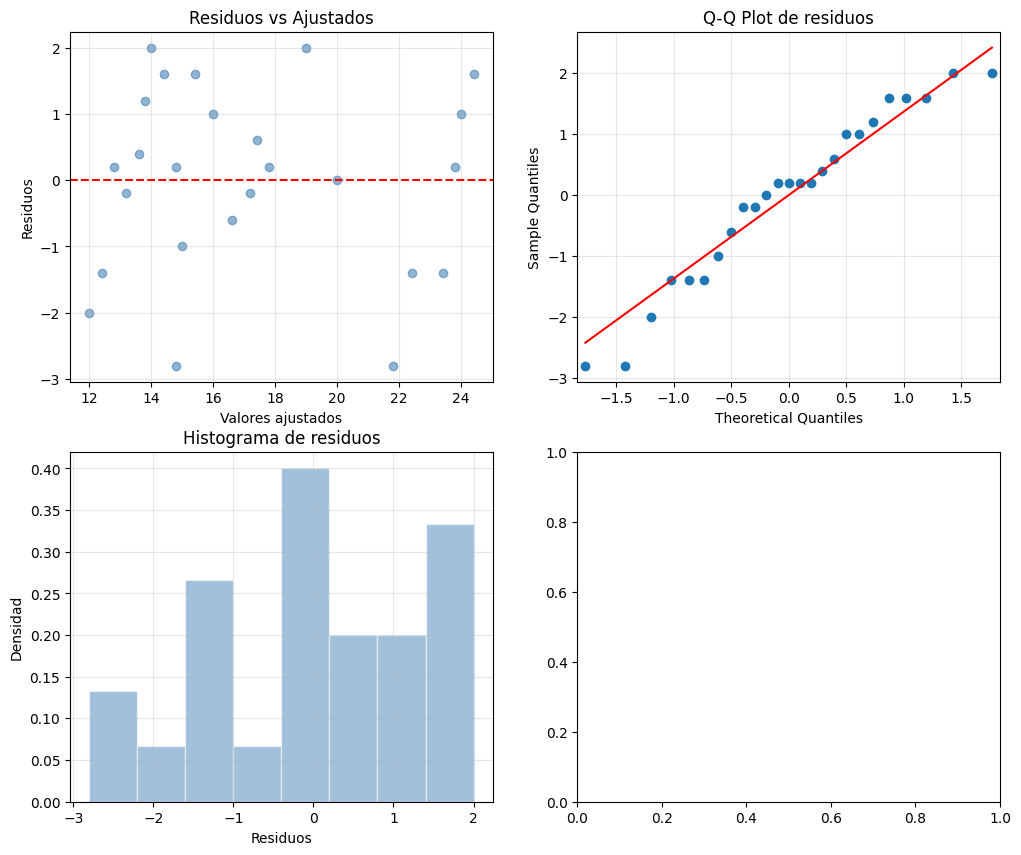

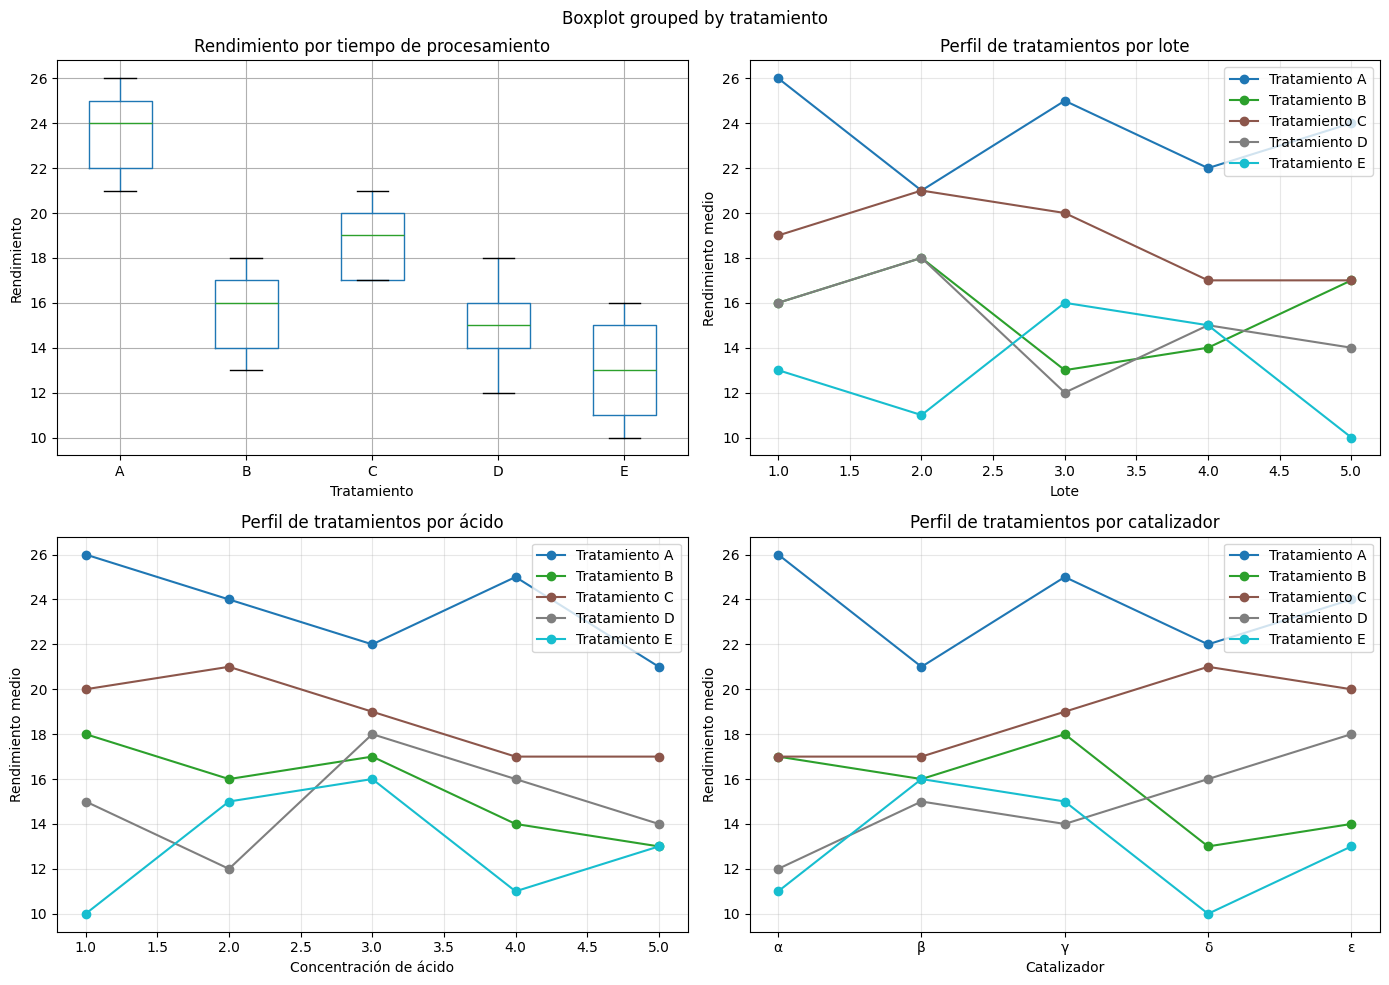

In [ ]:
# ============================================
# @title **C. EJEMPLO: DISEÑO EN CUADRO GRECOLATINO**
# RENDIMIENTO DE PROCESO QUÍMICO
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import shapiro

# Datos
rendimiento = [26, 16, 19, 16, 13,
               18, 21, 18, 11, 21,
               20, 12, 16, 25, 13,
               15, 15, 22, 14, 17,
               10, 24, 17, 17, 14]

lote = [1]*5 + [2]*5 + [3]*5 + [4]*5 + [5]*5
acido = [1,2,3,4,5]*5
tratamiento = ['A','B','C','D','E',
               'B','C','D','E','A',
               'C','D','E','A','B',
               'D','E','A','B','C',
               'E','A','B','C','D']
catalizador = ['α','β','γ','δ','ε',
               'γ','δ','ε','α','β',
               'ε','α','β','γ','δ',
               'β','γ','δ','ε','α',
               'δ','ε','α','β','γ']

datos = pd.DataFrame({
    'rendimiento': rendimiento,
    'lote': lote,
    'acido': acido,
    'tratamiento': tratamiento,
    'catalizador': catalizador
})

# Convertir a categóricas
datos['lote'] = datos['lote'].astype('category')
datos['acido'] = datos['acido'].astype('category')
datos['tratamiento'] = datos['tratamiento'].astype('category')
datos['catalizador'] = datos['catalizador'].astype('category')

# ============================================
# 1. ESTADÍSTICOS DESCRIPTIVOS
# ============================================
print("=== MEDIAS POR TRATAMIENTO (TIEMPO) ===")
print(datos.groupby('tratamiento')['rendimiento'].agg(['count', 'mean', 'std']))

print("\n=== MEDIAS POR LOTE ===")
print(datos.groupby('lote')['rendimiento'].agg(['count', 'mean', 'std']))

print("\n=== MEDIAS POR CONCENTRACIÓN DE ÁCIDO ===")
print(datos.groupby('acido')['rendimiento'].agg(['count', 'mean', 'std']))

print("\n=== MEDIAS POR CATALIZADOR ===")
print(datos.groupby('catalizador')['rendimiento'].agg(['count', 'mean', 'std']))

# ============================================
# 2. ANOVA PARA CUADRO GRECOLATINO
# ============================================
modelo_gcl = ols('rendimiento ~ C(tratamiento) + C(lote) + C(acido) + C(catalizador)',
                  data=datos).fit()
anova_gcl = sm.stats.anova_lm(modelo_gcl, typ=2)
print("\n=== ANOVA CUADRO GRECOLATINO ===")
print(anova_gcl)

# ============================================
# 3. COMPARACIONES MÚLTIPLES (Tukey HSD)
# ============================================
tukey = pairwise_tukeyhsd(datos['rendimiento'], datos['tratamiento'], alpha=0.05)
print("\n=== TUKEY HSD ===")
print(tukey)

# ============================================
# 4. VERIFICACIÓN DE SUPUESTOS
# ============================================
residuos = modelo_gcl.resid
valores_ajustados = modelo_gcl.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuos vs ajustados
axes[0, 0].scatter(valores_ajustados, residuos, alpha=0.6, color='steelblue')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Valores ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Ajustados')
axes[0, 0].grid(True, alpha=0.3)

# Q-Q plot
sm.qqplot(residuos, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot de residuos')
axes[0, 1].grid(True, alpha=0.3)

# Histograma de residuos
axes[1, 0].hist(residuos, bins=8, density=True, alpha=0.5,
                color='steelblue', edgecolor='white')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].set_title('Histograma de residuos')
axes[1, 0].grid(True, alpha=0.3)

# Prueba de Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(residuos)
print(f"\n=== PRUEBA DE SHAPIRO-WILK ===")
print(f"Estadístico W: {shapiro_stat:.4f}")
print(f"Valor-p: {shapiro_p:.4f}")

# ============================================
# 5. GRÁFICAS DE PERFIL
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot por tratamiento
datos.boxplot(column='rendimiento', by='tratamiento', ax=axes[0, 0])
axes[0, 0].set_title('Rendimiento por tiempo de procesamiento')
axes[0, 0].set_xlabel('Tratamiento')
axes[0, 0].set_ylabel('Rendimiento')

# Perfil por lote
colores = plt.cm.tab10(np.linspace(0, 1, 5))
for i, trat in enumerate(datos['tratamiento'].unique()):
    subdatos = datos[datos['tratamiento'] == trat]
    medias = subdatos.groupby('lote')['rendimiento'].mean()
    axes[0, 1].plot(medias.index, medias.values, 'o-',
                    color=colores[i], label=f'Tratamiento {trat}')
axes[0, 1].set_xlabel('Lote')
axes[0, 1].set_ylabel('Rendimiento medio')
axes[0, 1].set_title('Perfil de tratamientos por lote')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Perfil por ácido
for i, trat in enumerate(datos['tratamiento'].unique()):
    subdatos = datos[datos['tratamiento'] == trat]
    medias = subdatos.groupby('acido')['rendimiento'].mean()
    axes[1, 0].plot(medias.index, medias.values, 'o-',
                    color=colores[i], label=f'Tratamiento {trat}')
axes[1, 0].set_xlabel('Concentración de ácido')
axes[1, 0].set_ylabel('Rendimiento medio')
axes[1, 0].set_title('Perfil de tratamientos por ácido')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Perfil por catalizador
for i, trat in enumerate(datos['tratamiento'].unique()):
    subdatos = datos[datos['tratamiento'] == trat]
    medias = subdatos.groupby('catalizador')['rendimiento'].mean()
    axes[1, 1].plot(range(5), medias.values, 'o-',
                    color=colores[i], label=f'Tratamiento {trat}')
axes[1, 1].set_xticks(range(5))
axes[1, 1].set_xticklabels(['α', 'β', 'γ', 'δ', 'ε'])
axes[1, 1].set_xlabel('Catalizador')
axes[1, 1].set_ylabel('Rendimiento medio')
axes[1, 1].set_title('Perfil de tratamientos por catalizador')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio5)

<a name="T40"></a>
## **40. EJEMPLO: BIBD - ESTUDIO DE CATALIZADORES**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Totales por tratamiento: [218. 214. 216. 222.]
Totales por bloque: [221. 224. 207. 218.]

=== TABLA ANOVA PARA BIBD ===
Fuente                     SC    gl       CM        F    p-valor
-----------------------------------------------------------------
Tratamientos (aj)       22.75     3     7.58    14.00     0.0041
Bloques                 55.00     3        -        -          -
Error                    3.25     6     0.54        -          -
Total                   81.00    11        -        -          -

=== COMPARACIONES MÚLTIPLES (LSD) ===
LSD = 1.560

Medias por tratamiento:
Tratamiento 1: 72.67
Tratamiento 2: 71.33
Tratamiento 3: 72.00
Tratamiento 4: 74.00

Diferencias significativas (|diferencia| > LSD):
  Tratamiento 2 vs 4: 2.67 > 1.56 → Diferente
  Tratamiento 3 vs 4: 2.00 > 1.56 → Diferente


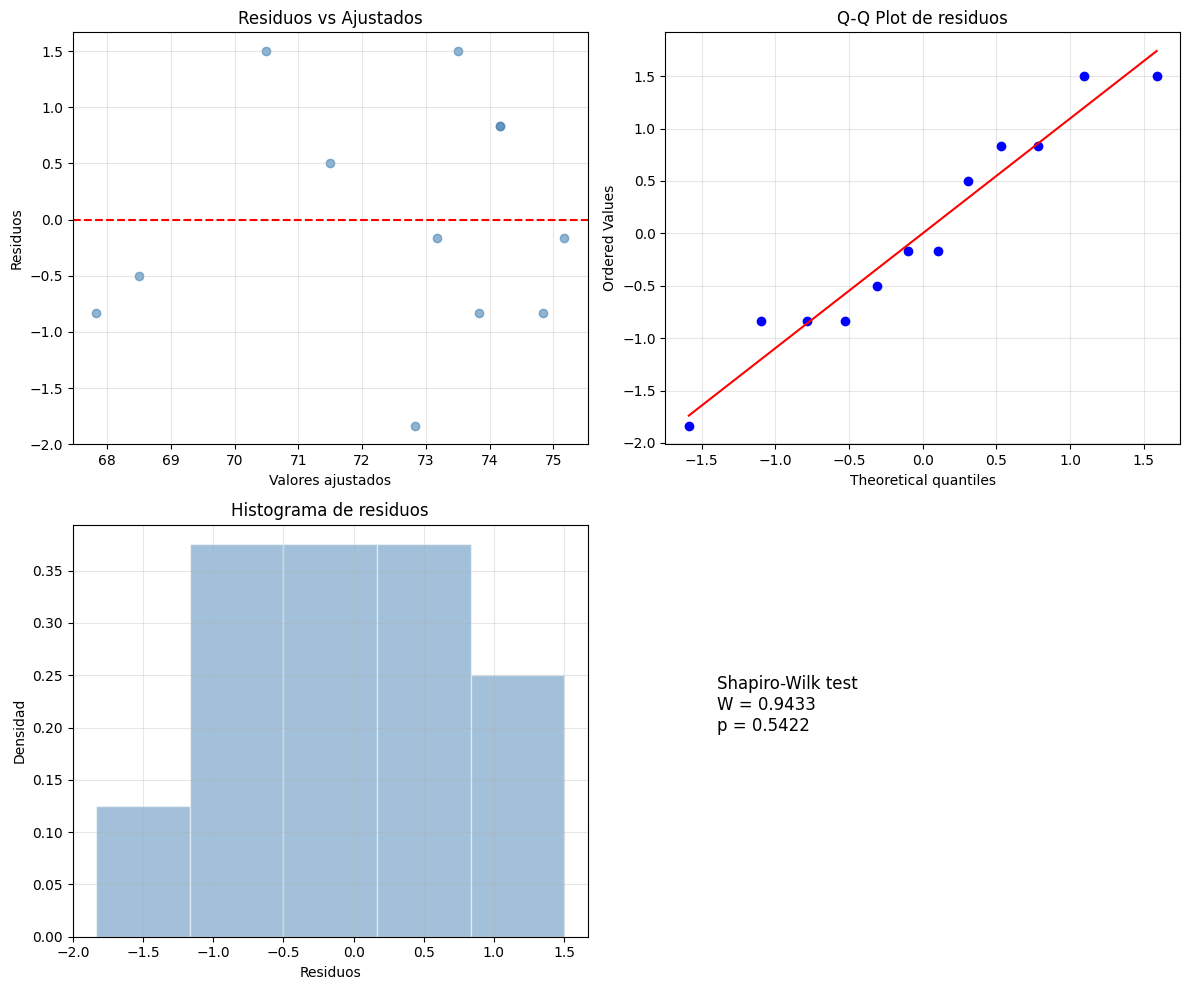


=== PRUEBA DE SHAPIRO-WILK ===
Estadístico W: 0.9433
Valor-p: 0.5422


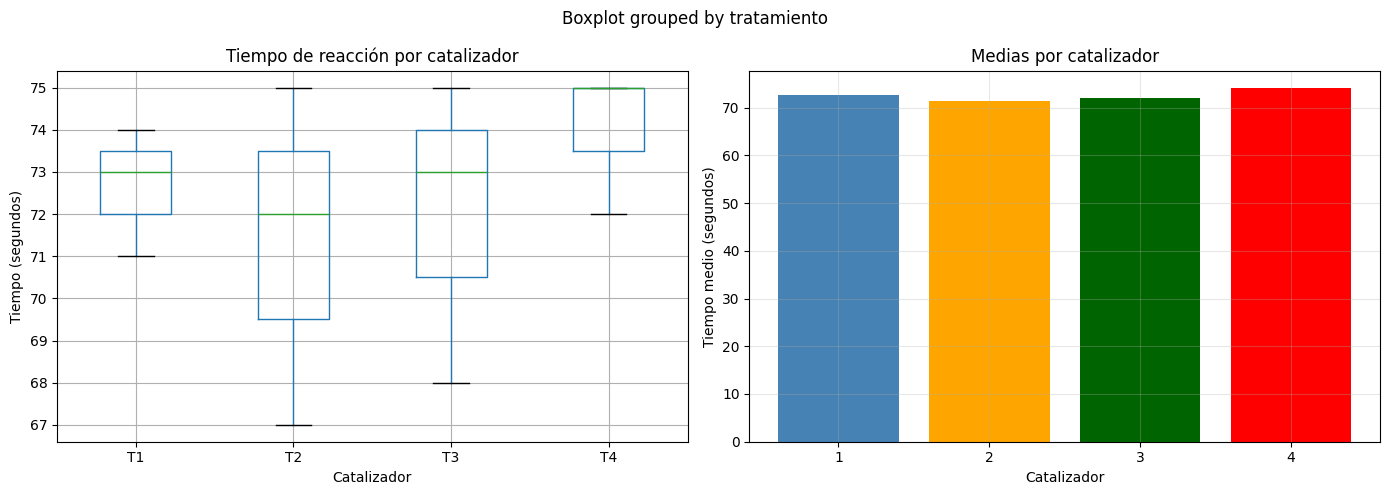

In [ ]:
# ============================================
# @title **C. EJEMPLO: BIBD - ESTUDIO DE CATALIZADORES**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import f, t

# Datos
tiempo = np.array([
    [73, 74, np.nan, 71],
    [np.nan, 75, 67, 72],
    [73, 75, 68, np.nan],
    [75, np.nan, 72, 75]
])

# Parámetros del diseño
a = 4  # tratamientos
b = 4  # bloques
k = 3  # tratamientos por bloque
r = 3  # réplicas por tratamiento
lambda_ = 2
N = 12

# Totales de tratamiento
Y_trat = np.nansum(tiempo, axis=1)
print("Totales por tratamiento:", Y_trat)

# Totales de bloque
Y_bloque = np.nansum(tiempo, axis=0)
print("Totales por bloque:", Y_bloque)

# Matriz de incidencia
n_ij = np.array([[1, 1, 0, 1],
                 [0, 1, 1, 1],
                 [1, 1, 1, 0],
                 [1, 0, 1, 1]])

# ============================================
# 1. CÁLCULO DE SUMAS DE CUADRADOS
# ============================================
Y_total = np.nansum(tiempo)
correccion = Y_total**2 / N

# Suma total de cuadrados
SCT = np.nansum(tiempo**2) - correccion

# Suma de cuadrados de bloques
SCB = (1/k) * np.sum(Y_bloque**2) - correccion

# Totales corregidos de tratamientos (Q_i)
sum_bloques_trat = np.sum(n_ij * Y_bloque, axis=1)
Q = Y_trat - (1/k) * sum_bloques_trat

# Suma de cuadrados de tratamientos ajustada
SCTr_aj = (k * np.sum(Q**2)) / (lambda_ * a)

# Suma de cuadrados del error
SCE = SCT - SCTr_aj - SCB

# Grados de libertad
gl_trat = a - 1
gl_bloque = b - 1
gl_error = N - a - gl_bloque + 1

# Cuadrados medios
CMTr_aj = SCTr_aj / gl_trat
CME = SCE / gl_error

# Estadístico F
F_calc = CMTr_aj / CME
p_valor = 1 - f.cdf(F_calc, gl_trat, gl_error)

print("\n=== TABLA ANOVA PARA BIBD ===")
print(f"{'Fuente':<20} {'SC':>8} {'gl':>5} {'CM':>8} {'F':>8} {'p-valor':>10}")
print("-" * 65)
print(f"{'Tratamientos (aj)':<20} {SCTr_aj:>8.2f} {gl_trat:>5} {CMTr_aj:>8.2f} {F_calc:>8.2f} {p_valor:>10.4f}")
print(f"{'Bloques':<20} {SCB:>8.2f} {gl_bloque:>5} {'-':>8} {'-':>8} {'-':>10}")
print(f"{'Error':<20} {SCE:>8.2f} {gl_error:>5} {CME:>8.2f} {'-':>8} {'-':>10}")
print(f"{'Total':<20} {SCT:>8.2f} {N-1:>5} {'-':>8} {'-':>8} {'-':>10}")

# ============================================
# 2. COMPARACIONES MÚLTIPLES
# ============================================
t_critico = t.ppf(0.975, gl_error)
LSD = t_critico * np.sqrt(2 * CME * k / (lambda_ * a))

print(f"\n=== COMPARACIONES MÚLTIPLES (LSD) ===")
print(f"LSD = {LSD:.3f}")

# Medias de tratamientos
medias_obs = np.nanmean(tiempo, axis=1)
print("\nMedias por tratamiento:")
for i, m in enumerate(medias_obs):
    print(f"Tratamiento {i+1}: {m:.2f}")

print("\nDiferencias significativas (|diferencia| > LSD):")
for i in range(4):
    for j in range(i+1, 4):
        diff = abs(medias_obs[i] - medias_obs[j])
        if diff > LSD:
            print(f"  Tratamiento {i+1} vs {j+1}: {diff:.2f} > {LSD:.2f} → Diferente")

# ============================================
# 3. VERIFICACIÓN DE SUPUESTOS
# ============================================
# Calcular valores ajustados
media_global = np.nanmean(tiempo)
Y_hat = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        if n_ij[i, j] == 1:
            media_trat = np.nanmean(tiempo[i, :])
            media_bloque = np.nanmean(tiempo[:, j])
            Y_hat[i, j] = media_trat + media_bloque - media_global

# Residuos
residuos = []
for i in range(4):
    for j in range(4):
        if not np.isnan(tiempo[i, j]):
            residuos.append(tiempo[i, j] - Y_hat[i, j])
residuos = np.array(residuos)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuos vs ajustados
val_ajustados = [Y_hat[i, j] for i in range(4) for j in range(4) if not np.isnan(tiempo[i, j])]
axes[0, 0].scatter(val_ajustados, residuos, alpha=0.6, color='steelblue')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Valores ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Ajustados')
axes[0, 0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(residuos, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot de residuos')
axes[0, 1].grid(True, alpha=0.3)

# Histograma
axes[1, 0].hist(residuos, bins=5, density=True, alpha=0.5, color='steelblue', edgecolor='white')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].set_title('Histograma de residuos')
axes[1, 0].grid(True, alpha=0.3)

# Prueba de Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuos)
axes[1, 1].text(0.1, 0.5, f'Shapiro-Wilk test\nW = {shapiro_stat:.4f}\np = {shapiro_p:.4f}',
                fontsize=12, transform=axes[1, 1].transAxes)
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n=== PRUEBA DE SHAPIRO-WILK ===")
print(f"Estadístico W: {shapiro_stat:.4f}")
print(f"Valor-p: {shapiro_p:.4f}")

# ============================================
# 4. GRÁFICAS DE PERFIL
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por tratamiento
tratamientos = []
valores = []
for i in range(4):
    for j in range(4):
        if not np.isnan(tiempo[i, j]):
            tratamientos.append(f'T{i+1}')
            valores.append(tiempo[i, j])
data = pd.DataFrame({'tratamiento': tratamientos, 'tiempo': valores})
data.boxplot(column='tiempo', by='tratamiento', ax=axes[0])
axes[0].set_title('Tiempo de reacción por catalizador')
axes[0].set_xlabel('Catalizador')
axes[0].set_ylabel('Tiempo (segundos)')

# Medias por tratamiento
axes[1].bar(range(1, 5), medias_obs, color=['steelblue', 'orange', 'darkgreen', 'red'])
axes[1].set_xlabel('Catalizador')
axes[1].set_ylabel('Tiempo medio (segundos)')
axes[1].set_title('Medias por catalizador')
axes[1].set_xticks(range(1, 5))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio5)